In [14]:
import cv2
import torch
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

image_dir = "../../Data/JPEGImages"
mask_dir = "../../Data/SegmentationClass"

images = []
masks = []

for name in os.listdir(image_dir):

    if not name.endswith(".jpg"):
        continue

    mask_name = name.replace(".jpg", ".png")
    mask_path = os.path.join(mask_dir, mask_name)

    if not os.path.exists(mask_path):
        continue


    image = cv2.imread(
        os.path.join(image_dir, name)
    )

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = np.array(
        Image.open(mask_path)
    )

    # person = 15
    mask = torch.tensor(mask == 15).long()

    images.append(
        torch.tensor(image)
    )

    masks.append(mask)


print("Number of images:", len(images))
print("Image shape:", images[0].shape)
print("Mask shape:", masks[0].shape)
print("Mask values:", torch.unique(masks[0]))

Number of images: 2913
Image shape: torch.Size([281, 500, 3])
Mask shape: torch.Size([281, 500])
Mask values: tensor([0, 1])


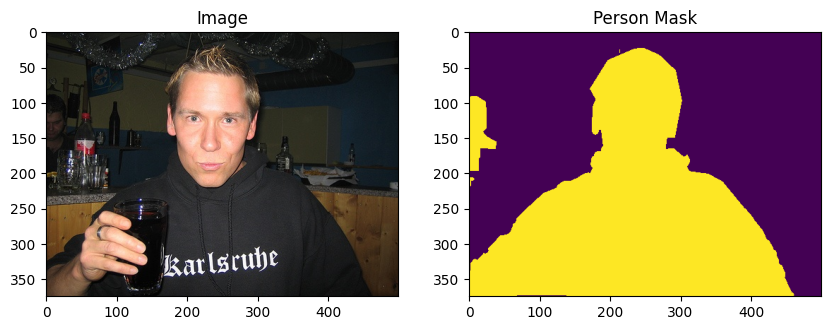

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images[10])
plt.title("Image")

plt.subplot(1, 2, 2)
plt.imshow(masks[10])
plt.title("Person Mask")

plt.show()